In [2]:
# Подключение Python к базе, импорт необходимых библиотек

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

conn = sqlite3.connect(r'C:\Users\anast\OneDrive\Desktop\project\bike_project')

orders = pd.read_sql('SELECT * FROM orders', conn)
order_items = pd.read_sql('SELECT * FROM order_items', conn)
products = pd.read_sql('SELECT * FROM products', conn)
customers = pd.read_sql('SELECT * FROM customers', conn)
stores = pd.read_sql('SELECT * FROM stores', conn)
categories = pd.read_sql('SELECT * FROM categories', conn)
brands = pd.read_sql('SELECT * FROM brands', conn)

pd.options.display.float_format = '{:,.2f}'.format

In [3]:
# Подсчет выручки по каждому заказу

order_items['revenue'] = (
    order_items['quantity'] * order_items['list_price'] * (1 - order_items['discount'])
)

order_revenue = order_items.groupby('order_id')['revenue'].sum().reset_index()

orders = orders.merge(order_revenue, on='order_id', how='left')
orders['order_date'] = pd.to_datetime(orders['order_date'])

print('Total revenue:', round(orders['revenue'].sum(), 2)) # подсчет и вывод общей выручки (по всем заказам)
print('Total orders:', len(orders)) # подсчет и вывод общего количества заказов

Total revenue: 7689116.56
Total orders: 1615


In [4]:
# Подсчет среднего чека

aov = orders['revenue'].mean()
print(f'AOV: ${aov:,.2f}')

AOV: $4,761.06


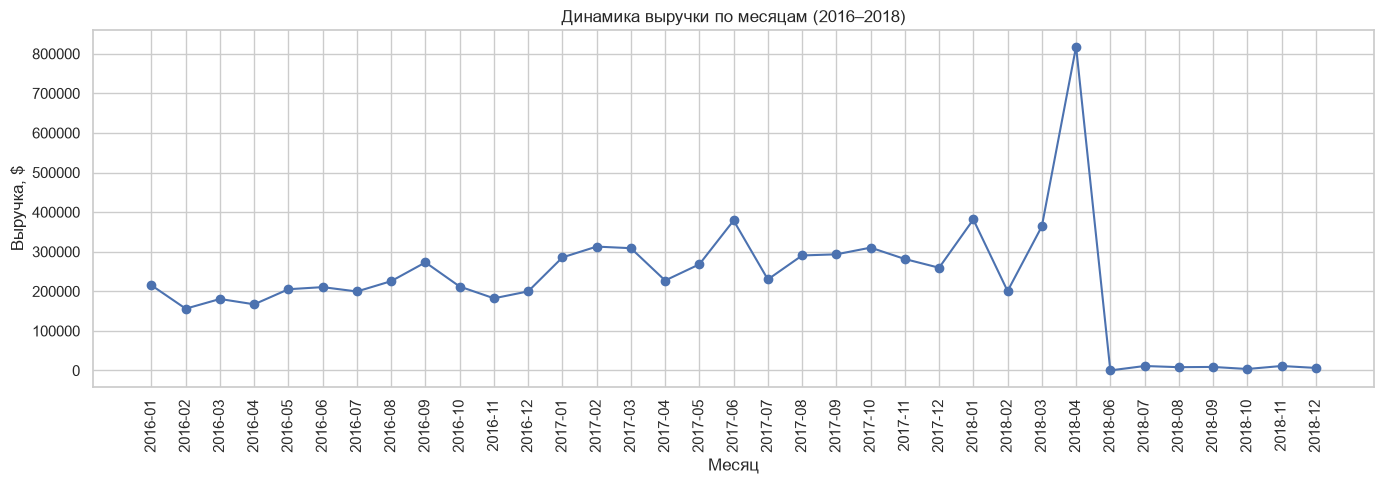

In [5]:
# Динамика выручки по месяцам, визуализация динамики

orders['month'] = orders['order_date'].dt.to_period('M').astype(str)
monthly_revenue = orders.groupby('month')['revenue'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'], marker='o')
plt.xticks(rotation=90)
plt.title('Динамика выручки по месяцам (2016–2018)')
plt.xlabel('Месяц')
plt.ylabel('Выручка, $')
plt.tight_layout()
plt.show()

Примечание

После марта 2018 датасет перестаёт отражать нормальную операционную активность: апрельский "пик" выручки на графике — это скопившиеся заказы в статусах Pending/Processing (ни одного завершенного заказа в статусе Completed), а с июня по декабрь 2018 присутствуют только единичные заказы, и все они имеют статус Rejected (отклонено). Наблюдаемая картина похожа на технический хвост данных, а не на реальное падение или всплеск продаж.

store_name
Baldwin Bikes      5,215,751.28
Santa Cruz Bikes   1,605,823.04
Rowlett Bikes        867,542.24
Name: revenue, dtype: float64


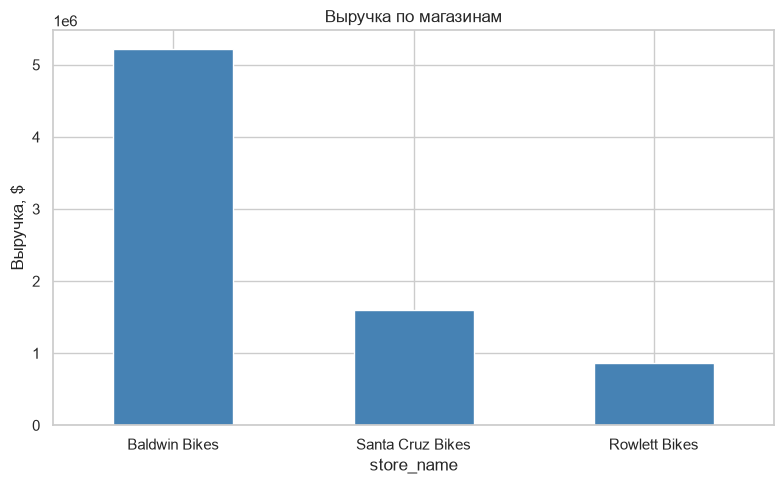

In [16]:
# Посчет выручки по каждому магазину с сортировкой по убыванию выручки и визуализацией

rev_by_store = (
    orders.merge(stores[['store_id', 'store_name']], on='store_id')
    .groupby('store_name')['revenue'].sum()
    .sort_values(ascending=False)
)
print(rev_by_store)

rev_by_store.plot(kind='bar', figsize=(8, 5), color='steelblue')
plt.title('Выручка по магазинам')
plt.ylabel('Выручка, $')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

category_name
Mountain Bikes        2,715,079.53
Road Bikes            1,665,098.49
Cruisers Bicycles       995,032.62
Electric Bikes          916,684.78
Cyclocross Bicycles     711,011.84
Comfort Bicycles        394,020.10
Children Bicycles       292,189.20
Name: revenue, dtype: float64


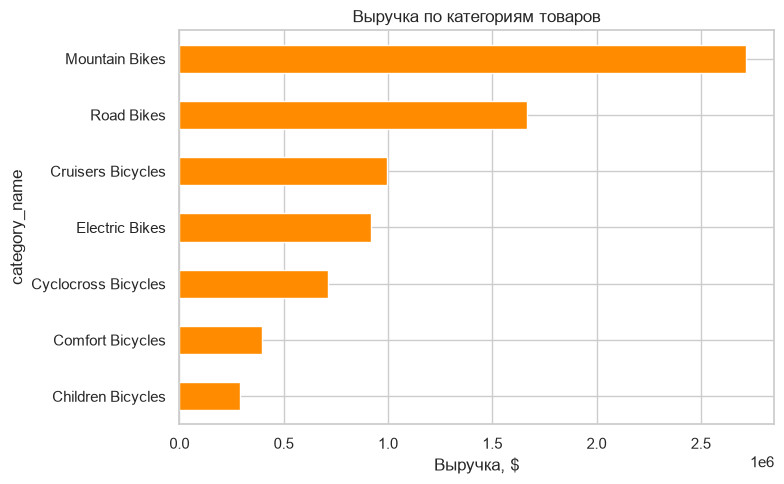

In [17]:
# Подсчет выручки по категориям товаров, визуализация

items_full = (
    order_items
    .merge(products, on='product_id')
    .merge(categories, on='category_id')
)

rev_by_category = (
    items_full.groupby('category_name')['revenue'].sum()
    .sort_values(ascending=False)
)
print(rev_by_category)

rev_by_category.plot(kind='barh', figsize=(8, 5), color='darkorange')
plt.title('Выручка по категориям товаров')
plt.xlabel('Выручка, $')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Средний LTV: 5321.19
Медианный LTV: 3859.93
customer_id
94   34,807.94
10   33,634.26
75   32,803.01
6    32,675.07
16   31,925.89
Name: revenue, dtype: float64


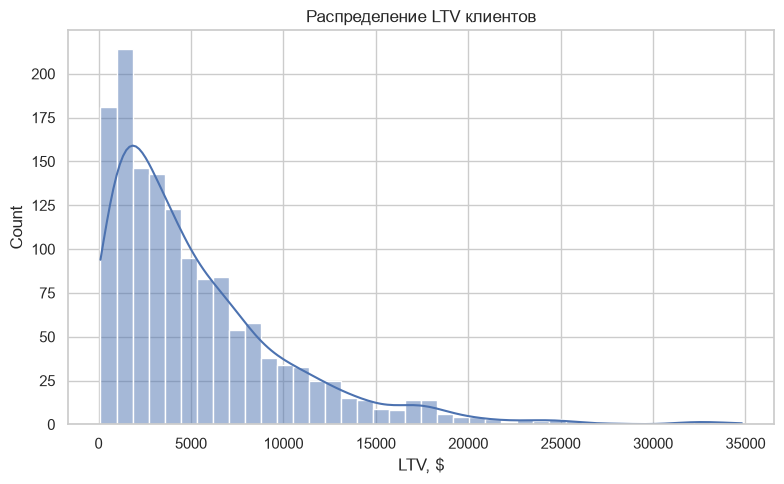

In [18]:
# Подсчет суммы всех покупок клиента за весь период данных, визуализация

ltv = orders.groupby('customer_id')['revenue'].sum().sort_values(ascending=False)

print('Средний LTV:', round(ltv.mean(), 2)) # вывод среднего LTV
print('Медианный LTV:', round(ltv.median(), 2)) # вывод медианного LTV
print(ltv.head()) # вывод идентификаторов первых пяти клиентов по объему LTV с указанием значения LTV

plt.figure(figsize=(8, 5))
sns.histplot(ltv, bins=40, kde=True)
plt.title('Распределение LTV клиентов') # визуализация распределения LTV
plt.xlabel('LTV, $')
plt.tight_layout()
plt.show()

In [19]:
# Подсчет давности последней покупки, частоты покупок и размера чека за все время данных по базовым статистическим показателям

snapshot_date = orders['order_date'].max() + pd.Timedelta(days=1)

rfm = orders.groupby('customer_id').agg(
    recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('revenue', 'sum')
).reset_index()

print(rfm.describe())

       customer_id  recency  frequency  monetary
count     1,445.00 1,445.00   1,445.00  1,445.00
mean        723.00   636.64       1.12  5,321.19
std         417.28   253.31       0.40  4,999.45
min           1.00     1.00       1.00    104.49
25%         362.00   425.00       1.00  1,681.48
50%         723.00   635.00       1.00  3,859.93
75%       1,084.00   849.00       1.00  7,176.21
max       1,445.00 1,093.00       3.00 34,807.94


In [20]:
# Сегментация клиентов по квантилям

rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

rfm['RM_score'] = rfm['R_score'] + rfm['M_score']

def segment(score):
    if score >= 7:
        return 'VIP / высокая ценность'
    elif score >= 5:
        return 'Стабильные клиенты'
    else:
        return 'Разовые / низкая активность'

rfm['segment'] = rfm['RM_score'].apply(segment)
print(rfm['segment'].value_counts())

segment
Разовые / низкая активность    611
Стабильные клиенты             508
VIP / высокая ценность         326
Name: count, dtype: int64


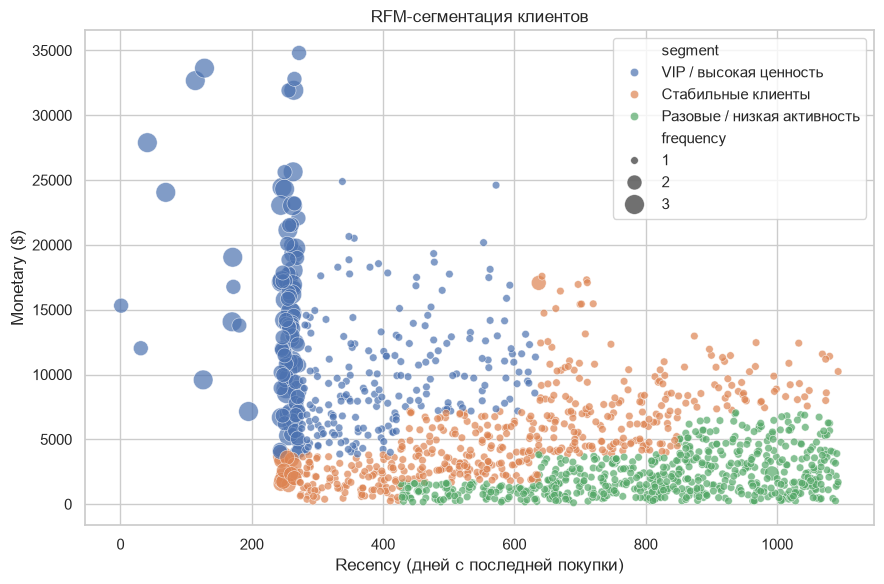

In [21]:
# Визуализация RFM-сегментации (размер точки -- 1, 2 или 3 -- соответствует количеству заказов конкретного клиента)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rfm, x='recency', y='monetary',
    hue='segment', size='frequency', sizes=(30, 200), alpha=0.7
)
plt.title('RFM-сегментация клиентов')
plt.xlabel('Recency (дней с последней покупки)')
plt.ylabel('Monetary ($)')
plt.tight_layout()
plt.show()

Основные выводы и наблюдения

- Общая выручка за период 2016–2018 гг. составила ~$7.69M, средний чек (AOV) — $4761
- Выручка сильно сконцентрирована вокруг определенной торговой точки: магазин Baldwin Bikes даёт ~68% всей выручки
- Mountain Bikes — самая продаваемая категория товаров, почти вдвое опережает Road Bikes — вторую по продаваемости категорию товаров
- LTV распределён с сильным правым хвостом за счет большого объема выручки со стороны наиболее "богатых" клентов: медиана $3 860 против среднего $5 321, топ-5 клиентов дают $31 900–$34 800 каждый
- 75% клиентов сделали только один заказ за 3 года, что ожидаемо для категории товара с длинным циклом повторной покупки; VIP-сегмент по RFM даёт непропорционально большую долю выручки относительно размера сегмента — для увеличения выручки магазина стоит сконцентрироваться на привлечении и удержании клиентов именно VIP-сегмента — например, с помощью внедрения специальных предложений на премиальные товары